Katiely Feitosa de Lacerda
NUSP: 12777100

# Instalando as dependências

In [1]:
!pip install EoN networkx numpy matplotlib dash dash-cytoscape


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


#  Epidemias

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import EoN
import random
import logging
import socket
import threading
import time
import webbrowser
import flask.cli
from dash import Dash, dcc, html, Input, Output
import dash_cytoscape as cyto
from IPython.display import HTML, display


N = 1000
k_medio = 8


tau = 0.3       # taxa de transmissão
gamma = 0.1     # taxa de recuperação (para SIR e SIS)
tmax = 60
num_infectados_iniciais = 10

# reprodutibilidade
seed = 42
np.random.seed(seed)
random.seed(seed)

In [3]:
def rede_ER(N=1000, k_medio=8, seed=None):
    # Erdős-Rényi, com  p = <k> / (N - 1)
    p = k_medio / (N - 1)
    return nx.erdos_renyi_graph(N, p, seed=seed)


def rede_BA(N=1000, k_medio=8, seed=None):
    # Rede Barabási-Albert, como o grau médio é aproximadamente 2m, para <k>=8, usamos m=4
    m = k_medio // 2
    return nx.barabasi_albert_graph(N, m, seed=seed)


def rede_WS(N=1000, k_medio=8, p=0.001, seed=None):
    # Rede Watts-Strogatz, sendo k um número par
    return nx.watts_strogatz_graph(N, k_medio, p, seed=seed)


def rede_BA_nao_linear(N=1000, k_medio=8, alpha=1.0, seed=None):
    #Rede BA não-linear.
    #A probabilidade de um novo nó se conectar ao nó i é proporcional a grau(i)^alpha
    # alpha = 1.0 se aproxima do BA tradicional.
    # alpha < 1.0 reduz o efeito dos hubs.
    # alpha > 1.0 aumenta o efeito dos hubs.

    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    m = k_medio // 2

    # Começa com uma rede completa pequena
    G = nx.complete_graph(m + 1)

    for novo_no in range(m + 1, N):
        graus = np.array([G.degree(n) for n in G.nodes()], dtype=float)

        # Evita grau zero
        pesos = graus ** alpha
        pesos = pesos / pesos.sum()

        nos_existentes = list(G.nodes())

        escolhidos = np.random.choice(
            nos_existentes,
            size=m,
            replace=False,
            p=pesos
        )

        G.add_node(novo_no)

        for alvo in escolhidos:
            G.add_edge(novo_no, alvo)

    return G

In [4]:
def infectados_iniciais(G, quantidade=10):
    # Alguns nós aleatórios são infectados primeiramente
    return random.sample(list(G.nodes()), quantidade)

# suscetível -> infectado
def simular_SI(G, tau=0.3, tmax=60, quantidade_inicial=10):
    # Como não há recuperação, SIR tem gamma = 0.
    iniciais = infectados_iniciais(G, quantidade_inicial)

    t, S, I, R = EoN.fast_SIR(
        G,
        tau=tau,
        gamma=0,
        initial_infecteds=iniciais,
        tmax=tmax
    )

    return t, I / G.number_of_nodes()

# suscetível -> infectado -> recuperado
def simular_SIR(G, tau=0.3, gamma=0.1, tmax=60, quantidade_inicial=10):
    iniciais = infectados_iniciais(G, quantidade_inicial)

    t, S, I, R = EoN.fast_SIR(
        G,
        tau=tau,
        gamma=gamma,
        initial_infecteds=iniciais,
        tmax=tmax
    )

    return t, I / G.number_of_nodes(), R / G.number_of_nodes()

# suscetível -> infectado ->  suscetível novamente
def simular_SIS(G, tau=0.3, gamma=0.1, tmax=60, quantidade_inicial=10):
    iniciais = infectados_iniciais(G, quantidade_inicial)

    t, S, I = EoN.fast_SIS(
        G,
        tau=tau,
        gamma=gamma,
        initial_infecteds=iniciais,
        tmax=tmax
    )

    return t, I / G.number_of_nodes()

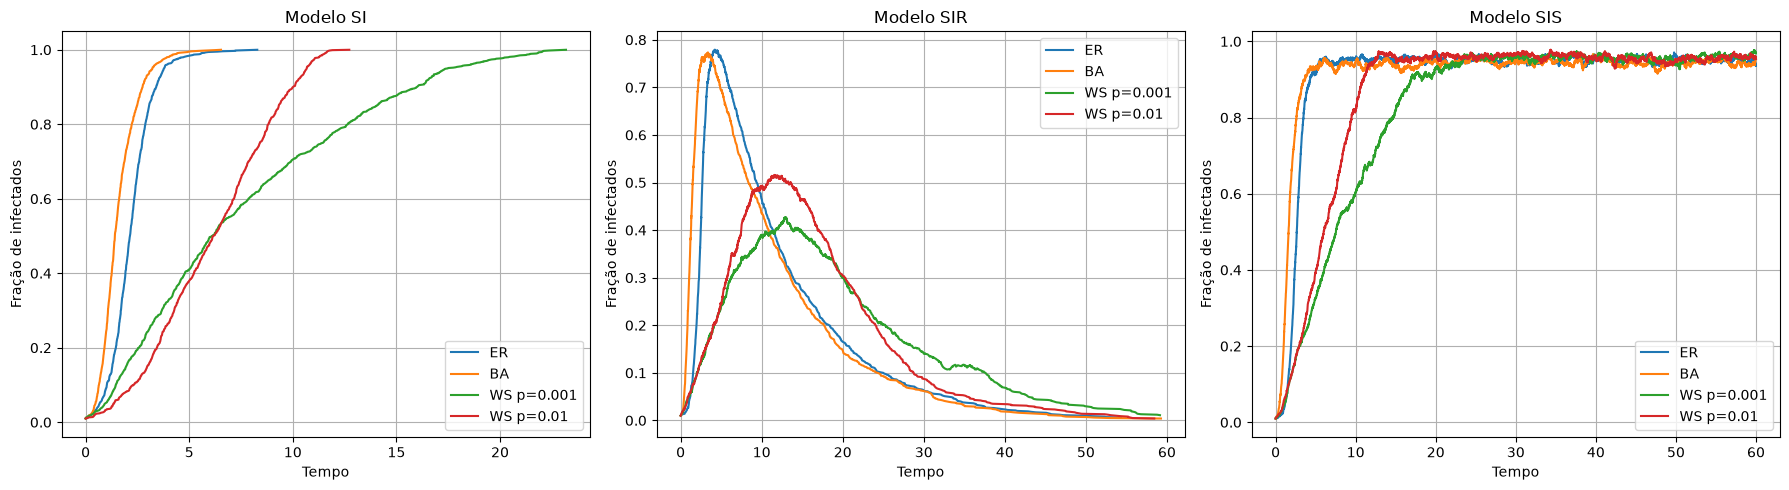

In [ ]:
redes = {
    "ER": rede_ER(N, k_medio, seed=1),
    "BA": rede_BA(N, k_medio, seed=2),
    "WS p=0.001": rede_WS(N, k_medio, p=0.001, seed=3),
    "WS p=0.01": rede_WS(N, k_medio, p=0.01, seed=4)
}

# Faz uma aplicacao web local com Dash Cytoscape
# É um modo interativo de ver e interpretar as redes
def elementos_cytoscape(G, nome_rede):
    graus = dict(G.degree())
    valores_grau = list(graus.values())
    limiar_hubs = np.percentile(valores_grau, 95)
    pos = nx.spring_layout(G, seed=seed, iterations=35, k=0.08)
    escala = 900

    elementos = []
    for no in G.nodes():
        grau = graus[no]
        eh_hub = grau >= limiar_hubs
        elementos.append({
            "data": {
                "id": str(no),
                "label": str(no) if eh_hub else "",
                "degree": int(grau),
                "network": nome_rede,
                "hub": "sim" if eh_hub else "nao"
            },
            "position": {
                "x": float(pos[no][0] * escala),
                "y": float(pos[no][1] * escala)
            },
            "classes": "hub" if eh_hub else "normal"
        })

    for origem, destino in G.edges():
        elementos.append({
            "data": {
                "source": str(origem),
                "target": str(destino)
            }
        })

    return elementos


elementos_por_rede = {
    nome_rede: elementos_cytoscape(G, nome_rede)
    for nome_rede, G in redes.items()
}
grau_maximo = max(grau for G in redes.values() for _, grau in G.degree())


def porta_livre(inicio=8050, tentativas=50):
    for porta in range(inicio, inicio + tentativas):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            if s.connect_ex(("127.0.0.1", porta)) != 0:
                return porta
    raise RuntimeError("Nao existe porta livre no momento para abir a visualização.")


porta_redes = porta_livre()
url_redes = f"http://127.0.0.1:{porta_redes}"

app_redes = Dash(__name__)
app_redes.layout = html.Div([
    html.Div([
        html.Label("Redes"),
        dcc.Dropdown(
            id="seletor-rede",
            options=[{"label": nome, "value": nome} for nome in redes.keys()],
            value="BA",
            clearable=False
        ),
        html.Div(id="info-rede", style={"marginTop": "12px", "fontFamily": "Arial"}),
        html.Div(id="info-no", style={"marginTop": "8px", "fontFamily": "Arial"})
    ], style={"width": "280px", "display": "inline-block", "verticalAlign": "top", "padding": "12px"}),
    html.Div([
        cyto.Cytoscape(
            id="grafo-rede",
            elements=elementos_por_rede["BA"],
            layout={"name": "preset"},
            style={"width": "100%", "height": "760px", "border": "1px solid #dddddd"},
            minZoom=0.08,
            maxZoom=4,
            stylesheet=[
                {
                    "selector": "node",
                    "style": {
                        "width": f"mapData(degree, 0, {grau_maximo}, 6, 46)",
                        "height": f"mapData(degree, 0, {grau_maximo}, 6, 46)",
                        "background-color": "#1f77b4",
                        "label": "data(label)",
                        "font-size": "9px",
                        "color": "#222222"
                    }
                },
                {
                    "selector": ".hub",
                    "style": {
                        "background-color": "#d62728",
                        "z-index": 10
                    }
                },
                {
                    "selector": "edge",
                    "style": {
                        "line-color": "#999999",
                        "opacity": 0.18,
                        "width": 0.6
                    }
                }
            ]
        )
    ], style={"width": "calc(100% - 320px)", "display": "inline-block"})
])


@app_redes.callback(
    Output("grafo-rede", "elements"),
    Output("info-rede", "children"),
    Input("seletor-rede", "value")
)
def atualizar_rede(nome_rede):
    G = redes[nome_rede]
    graus = [grau for _, grau in G.degree()]
    info = f"{nome_rede}: {G.number_of_nodes()} vertices, {G.number_of_edges()} arestas, grau medio = {np.mean(graus):.2f}."
    return elementos_por_rede[nome_rede], info


@app_redes.callback(
    Output("info-no", "children"),
    Input("grafo-rede", "tapNodeData")
)
def mostrar_no(no):
    if no is None:
        return "Clique em um vertice para ver o grau. Vertices vermelhos são hubs."
    return f"Vertice {no['id']} | grau = {no['degree']} | hub = {no['hub']}"


def executar_app_redes():
    # Usamos o servidor Flask direto para evitar que o Jupyter renderize o app dentro da celula.
    flask.cli.show_server_banner = lambda *args, **kwargs: None
    logging.getLogger("werkzeug").setLevel(logging.ERROR)
    app_redes.server.run(host="127.0.0.1", port=porta_redes, debug=False, use_reloader=False)


thread_redes = threading.Thread(target=executar_app_redes, daemon=True)
thread_redes.start()
time.sleep(1)

display(HTML(
    f'<p><a href="{url_redes}" target="_blank" rel="noopener noreferrer">Abrir visualizacao interativa das redes</a></p>'
))

try:
    webbrowser.open_new_tab(url_redes)
except Exception:
    pass

modelos = ["SI", "SIR", "SIS"]

plt.figure(figsize=(18, 5))

for idx, modelo in enumerate(modelos, 1):
    plt.subplot(1, 3, idx)
    for nome_rede, G in redes.items():
        if modelo == "SI":
            t, I = simular_SI(G, tau=tau, tmax=tmax, quantidade_inicial=num_infectados_iniciais)
        elif modelo == "SIR":
           t, I, R = simular_SIR(G, tau=tau, gamma=gamma, tmax=tmax, quantidade_inicial=num_infectados_iniciais)
        elif modelo == "SIS":
            t, I = simular_SIS(G, tau=tau, gamma=gamma, tmax=tmax, quantidade_inicial=num_infectados_iniciais)
        plt.plot(t, I, label=nome_rede)

    plt.title(f"Modelo {modelo}")
    plt.xlabel("Tempo")
    plt.ylabel("Fração de infectados")
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

Para melhorar a interpretação pode-se abir o link acima dos gráficos onde diz "Abir visualização interativa das redes"

Modelo SI: A fração de infectados cresce até atingir praticamente toda a rede, e isso acontece porque, nesse modelo, os indivíduos infectados não se recuperam ( Suscetível -> Infectado ), ou seja, uma vez infectado, o vértice permanece infectado até o fim da simulação. As redes BA (existem alguns nós muito conectados, chamados hubs. Algumas pessoas conhecem muita gente
a maioria conhece poucas pessoas) e ER(as conexões são sorteadas aleatoriamente, e nesse caso a rede tem  conexões bem espalhadas) mostram crescimento mais rápido da epidemia, chegando perto de 100% de infectados em pouco tempo. Já a rede WS(os nós começam conectados mais com “vizinhos próximos”, e algumas conexões são trocadas por atalhos aleatórios)  com p = 0.001 apresenta propagação mais lenta, pois sua estrutura é mais regular e possui poucos atalhos aleatórios, diminuindo o tempo de disseminação entre regiões distantes da rede. As redes ER e BA atingem o pico de infectados mais cedo, indicando uma propagação inicial mais rápida. No caso da rede BA, esse comportamento pode ser explicado pela presença de hubs, ou seja, vértices com muitas conexões. Quando esses vértices são infectados, eles conseguem transmitir a doença para muitos outros nós em pouco tempo.
Já as redes WS, principalmente com p = 0.001, apresentam um pico mais tardio e mais distribuído ao longo do tempo. Isso indica uma propagação mais lenta, pois a rede possui uma estrutura mais local e poucos atalhos aleatórios, dificultando que a infecção alcance rapidamente regiões distantes da rede.


No modelo SIR, a curva de infectados primeiro cresce rápido, atinge um pico e depois diminui. Isso ocorre porque os indivíduos passam de suscetíveis para infectados e, depois, para recuperados. Como os recuperados não voltam a ser infectados, a epidemia tende a perder força com o tempo. As redes ER e BA atingem o pico de infectados mais cedo, indicando uma propagação inicial mais rápida. No caso da rede BA, esse comportamento pode ser explicado provavelmente pela presença de hubs  (vértices com muitas conexões). Quando esses vértices são infectados, eles conseguem transmitir a doença para muitos outros nós em pouco tempo. Já as redes WS, principalmente com p = 0.001, apresentam um pico mais tardio e mais distribuído ao longo do tempo. Isso indica uma propagação mais lenta, pois a rede possui uma estrutura mais local e poucos atalhos aleatórios, isso dificulta o alcance da infecção rapidamente em regiões distantes da rede.


Modelo SIS: A fração de infectados cresce e depois permanece em valores elevados. Isso acontece porque os indivíduos passam de suscetíveis para infectados, mas, ao se recuperarem, voltam novamente ao estado suscetível. Portanto, eles podem ser infectados mais de uma vez.As redes ER e BA atingem rapidamente uma alta fração de infectados. Na rede BA, novamente, a presença de hubs facilita a propagação da epidemia, pois poucos vértices muito conectados conseguem espalhar a infecção para grande parte da rede. Na ER, as conexões aleatórias também mostraram o favorecimnento de uma disseminação rápida entre diferentes partes da rede.
Nas redes WS, especialmente com p = 0.001, o crescimento da curva é mais lento, porque há poucos atalhos aleatórios, fazendo com que a transmissão aconteça de forma mais local. Com p = 0.01, a propagação é mais rápida, pois existem mais atalhos ligando regiões diferentes da rede. Mesmo assim, no modelo SIS, a epidemia tende a se manter ativa por mais tempo, já que os indivíduos recuperados podem voltar a ser infectados.


# Imunização

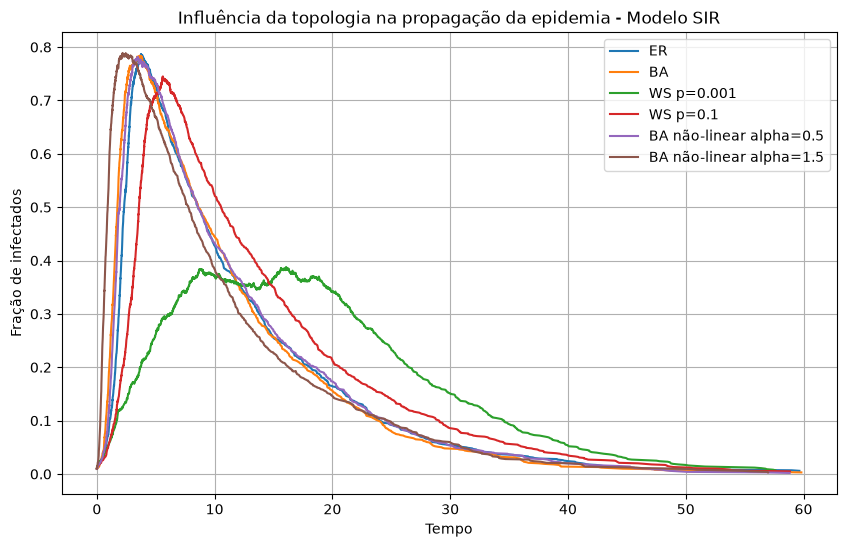

In [7]:
topologica_nas_redes = {
    "ER": rede_ER(N, k_medio, seed=10),
    "BA": rede_BA(N, k_medio, seed=11),
    "WS p=0.001": rede_WS(N, k_medio, p=0.001, seed=12),
    "WS p=0.1": rede_WS(N, k_medio, p=0.1, seed=13),
    "BA não-linear alpha=0.5": rede_BA_nao_linear(N, k_medio, alpha=0.5, seed=14),
    "BA não-linear alpha=1.5": rede_BA_nao_linear(N, k_medio, alpha=1.5, seed=15),
}
plt.figure(figsize=(10, 6))

for nome_rede, G in topologica_nas_redes.items():
    t, I, R = simular_SIR(
        G,
        tau=tau,
        gamma=gamma,
        tmax=tmax,
        quantidade_inicial=num_infectados_iniciais
    )
    plt.plot(t, I, label=nome_rede)

plt.title("Influência da topologia na propagação da epidemia - Modelo SIR")
plt.xlabel("Tempo")
plt.ylabel("Fração de infectados")
plt.legend()
plt.grid(True)
plt.show()

Usei o modelo SIR
Podemos ver que as edes com hubs ou mais atalhos favorecem uma disseminação mais rápida, enquanto redes mais locais retardam a propagação. 


In [8]:
def rodar_SIR_com_imunizacao(G_original, percentual_imunizado, tipo="aleatoria", tau=0.3, gamma=0.1, tmax=60):

    # Uma fração de vértices estará imunizado.
    # Tipo = "aleatoria" ou "hubs"
    # Os imunizados são removidos da rede antes da epidemia
    # Depois calculamos a fração de recuperados em relação ao N original

    G = G_original.copy()
    N_original = G_original.number_of_nodes()

    quantidade_imunizada = int(percentual_imunizado * N_original)

    if quantidade_imunizada == 0:
        imunizados = []

    elif tipo == "aleatoria":
        imunizados = random.sample(list(G.nodes()), quantidade_imunizada)

    elif tipo == "hubs":
        graus_ordenados = sorted(G.degree(), key=lambda x: x[1], reverse=True)
        imunizados = [no for no, grau in graus_ordenados[:quantidade_imunizada]]

    else:
        raise ValueError("tipo precisa ser 'aleatoria' ou 'hubs'")

    # Removendo os imunizados
    G.remove_nodes_from(imunizados)

    # Se a rede ficou vazia ou quase vazia
    if G.number_of_nodes() <= num_infectados_iniciais:
        return 0

    iniciais = random.sample(list(G.nodes()), num_infectados_iniciais)

    t, S, I, R = EoN.fast_SIR(
        G,
        tau=tau,
        gamma=gamma,
        initial_infecteds=iniciais,
        tmax=tmax
    )

    recuperados_finais = R[-1]

    r = recuperados_finais / N_original

    return r

In [9]:
G_BA_imunizacao = rede_BA(N, k_medio, seed=100)

percentuais = np.linspace(0, 0.9, 10)
num_repeticoes = 10

medias_aleatoria = []
desvios_aleatoria = []

medias_hubs = []
desvios_hubs = []

for x in percentuais:
    resultados_aleatoria = []
    resultados_hubs = []

    for repeticao in range(num_repeticoes):
        r_aleatoria = rodar_SIR_com_imunizacao(
            G_BA_imunizacao,
            percentual_imunizado=x,
            tipo="aleatoria",
            tau=tau,
            gamma=gamma,
            tmax=tmax
        )

        r_hubs = rodar_SIR_com_imunizacao(
            G_BA_imunizacao,
            percentual_imunizado=x,
            tipo="hubs",
            tau=tau,
            gamma=gamma,
            tmax=tmax
        )

        resultados_aleatoria.append(r_aleatoria)
        resultados_hubs.append(r_hubs)

    medias_aleatoria.append(np.mean(resultados_aleatoria))
    desvios_aleatoria.append(np.std(resultados_aleatoria))

    medias_hubs.append(np.mean(resultados_hubs))
    desvios_hubs.append(np.std(resultados_hubs))

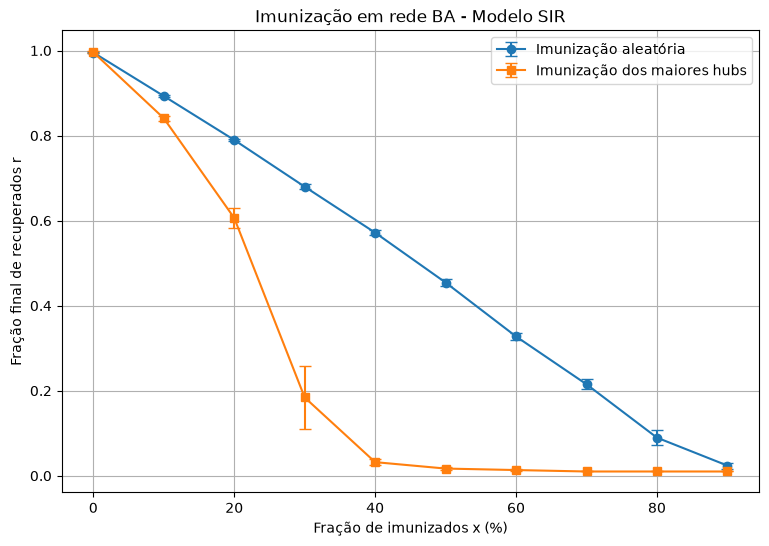

In [10]:
percentuais_plot = percentuais * 100

plt.figure(figsize=(9, 6))

plt.errorbar(
    percentuais_plot,
    medias_aleatoria,
    yerr=desvios_aleatoria,
    marker="o",
    capsize=4,
    label="Imunização aleatória"
)

plt.errorbar(
    percentuais_plot,
    medias_hubs,
    yerr=desvios_hubs,
    marker="s",
    capsize=4,
    label="Imunização dos maiores hubs"
)

plt.title("Imunização em rede BA - Modelo SIR")
plt.xlabel("Fração de imunizados x (%)")
plt.ylabel("Fração final de recuperados r")
plt.legend()
plt.grid(True)
plt.show()

Podemos ver que quando não há imunização, a epidemia atinge praticamente toda a rede, resultando em uma fração final de recuperados próxima de 1. À medida que a fração de imunizados aumenta, a fração final de recuperados diminui, indicando que a epidemia passa a atingir uma parcela menor da população.A imunização dos maiores hubs se mostrou muito mais efetiva do que a imunização aleatória. Isso pode ser observado pela queda mais acentuada da curva correspondente aos hubs(laranja). Com uma fração relativamente pequena de hubs imunizados, a epidemia já é fortemente reduzida. Isso ocorre porque redes BA possuem vértices altamente conectados, que funcionam como pontos centrais de disseminação. Ao imunizar esses vértices, muitos caminhos importantes de transmissão são bloqueados.Por outro lado, a imunização aleatória apresenta redução mais gradual da epidemia, pois pode selecionar vértices com poucas conexões, deixando hubs importantes ainda ativos na rede.
Então a estratégia baseada na imunização dos maiores hubs é mais eficiente para conter a propagação da epidemia em redes BA.